# TV Marketing Linear Regression

This notebook trains a simple linear regression model to predict sales from TV advertising spend.

## Goal
- Load the CSV data
- Explore the relationship between TV and Sales
- Train a linear regression model
- Evaluate the model using MAE, RMSE, and R²
- Plot the regression line

      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9

Dataset shape: (200, 2)


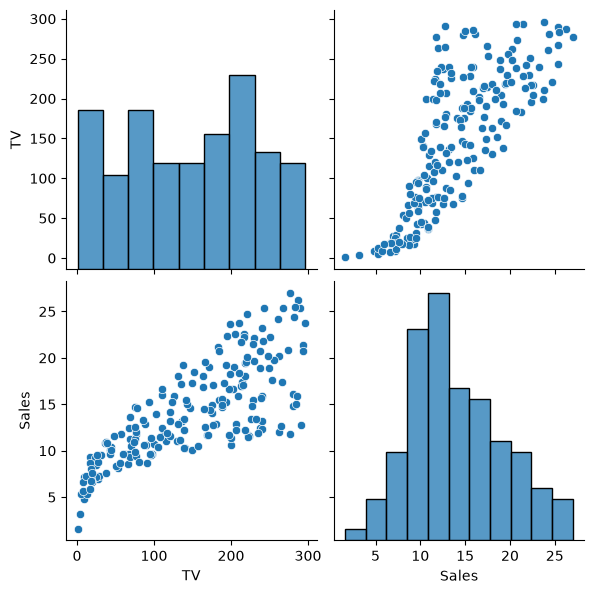

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
path = 'tvmarketing.csv'
df = pd.read_csv(path)

# Preview data
print(df.head())
print('\nDataset shape:', df.shape)

# Feature and target
X = df[['TV']]
y = df['Sales']

# Quick pair plot
sns.pairplot(df, height=3)
plt.show()

In [2]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Intercept:', model.intercept_)
print('Coefficient:', model.coef_[0])
print('MAE:', mae)
print('RMSE:', rmse)
print('R^2:', r2)

Intercept: 7.119638430592953
Coefficient: 0.046529733705443346
MAE: 2.444420003751042
RMSE: 3.194472431998898
R^2: 0.6766954295627076


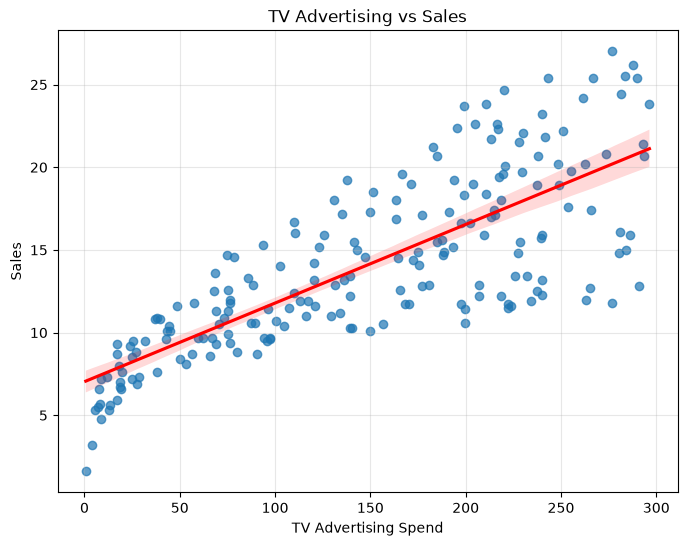

In [3]:
# Plot regression line
plt.figure(figsize=(8, 6))
sns.regplot(x='TV', y='Sales', data=df, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'})
plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()

Random Forest MAE: 2.303004999999991
Random Forest RMSE: 2.989419552027051
Random Forest R^2: 0.716869082499783

Linear Regression MAE: 2.444420003751042
Linear Regression RMSE: 3.194472431998898
Linear Regression R^2: 0.6766954295627076


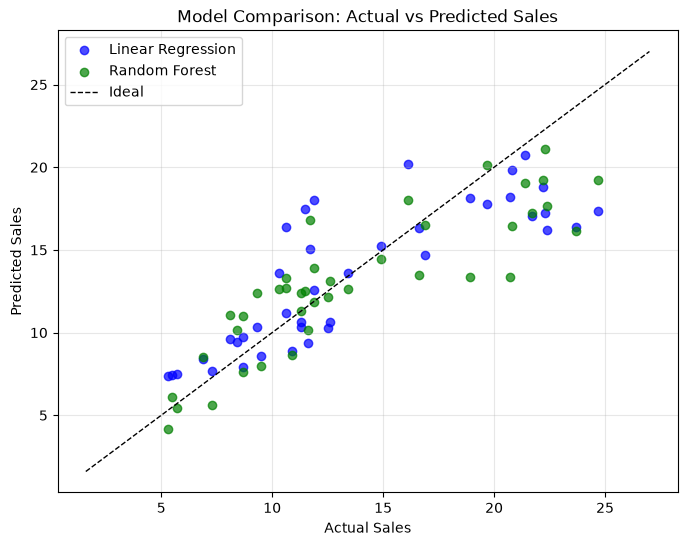

In [4]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest regression
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=None
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print('Random Forest MAE:', rf_mae)
print('Random Forest RMSE:', rf_rmse)
print('Random Forest R^2:', rf_r2)

# Compare against Linear Regression
print('\nLinear Regression MAE:', mae)
print('Linear Regression RMSE:', rmse)
print('Linear Regression R^2:', r2)

# Plot model comparison
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7, label='Linear Regression')
plt.scatter(y_test, rf_pred, color='green', alpha=0.7, label='Random Forest')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='black', linestyle='--', lw=1, label='Ideal')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Model Comparison: Actual vs Predicted Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()